# GBD_5 — Single-Beamlet Propagation

## What changed from GBD_4
GBD_4 built a basis of 135 tilted Gaussians and decomposed a top-hat field, but only at z = 0. It never propagated anything. GBD_5 takes a step back in scope so we can take a step forward in correctness: we pick **one** beamlet from the GBD_4 basis and propagate it analytically to several z values, verifying it matches the textbook Gaussian-beam formulas.

Once we trust one beamlet, GBD_6 will propagate the whole sum.

## What's new in this notebook
1. A Rayleigh-range calculation `zR = π·w₀²/λ`.
2. A `propagate_tilted_gaussian(...)` function using the complex q-parameter form.
3. Multi-z propagation with **amplitude AND phase** plots (FMCW cares about phase).
4. Diagnostics that print `w(z)`, `R(z)`, Gouy phase, and beam center.
5. A tilted-beam pass to show the centroid walks at `(kx/k)·z` per unit propagation.

## What's intentionally NOT here yet
- The full 135-beamlet sum (next notebook: GBD_6).
- Angular-spectrum ground-truth comparison (GBD_7).
- Realistic LiDAR wavelength/beam size (Era 2).

We keep GBD_4's micrometer-scale numbers on purpose so this notebook is directly comparable to one column of GBD_4's `G` matrix at z = 0.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Same x-grid and wavelength as GBD_4 (units in micrometers)
# --------------------------------------------------
x_min, x_max, Nx = -5.0, 5.0, 1000
x = np.linspace(x_min, x_max, Nx)

wavelength = 0.6328       # HeNe, micrometers
k = 2 * np.pi / wavelength  # free-space wave number

# --------------------------------------------------
# Pick one beamlet from the GBD_4 basis
# (centered at x=0, tilt-free for the first pass)
# --------------------------------------------------
x0 = 0.0   # transverse center at z=0
w0 = 0.5   # 1/e amplitude waist (same as GBD_4)
kx = 0.0   # no tilt yet

# Rayleigh range: the natural depth scale of a Gaussian beam.
# By z = zR the beam has grown to w0*sqrt(2); by z = 5*zR it's about 5x wider.
zR = np.pi * w0**2 / wavelength
print(f"Rayleigh range zR = {zR:.4f} micrometers")
print(f"  (very small because we're using GBD_4's sub-micron beam — that's fine for validation;")
print(f"   real LiDAR has w0 ~ mm so zR ~ meters. We'll switch later.)")

Rayleigh range zR = 1.2411 micrometers
  (very small because we're using GBD_4's sub-micron beam — that's fine for validation;
   real LiDAR has w0 ~ mm so zR ~ meters. We'll switch later.)


## The propagation function

We use the **q-parameter** form of the paraxial Gaussian beam. The complex parameter
$$q(z) = z + q_0, \qquad q_0 = -i z_R$$
encodes width, wavefront curvature, and Gouy phase together. Its real and imaginary parts give
$$\frac{1}{q(z)} = \frac{1}{R(z)} + i\,\frac{\lambda}{\pi w(z)^2}$$
(with appropriate sign convention). So once we know `q(z)`, we know everything.

The propagated 1-D Gaussian beam is
$$E(x, z) = \sqrt{\frac{q_0}{q(z)}}\;\exp\!\left(\frac{i k (x - x_c)^2}{2 q(z)}\right)\;\exp(i k_z z)\;\exp(i k_x x)$$
where the beam center walks: $x_c(z) = x_0 + (k_x/k) z$.

The amplitude `sqrt(q0/qz)` automatically gives the `sqrt(w0/w(z))` envelope scaling and half of the Gouy phase. The exponent gives the Gaussian envelope plus the curvature phase `+i·k·(x-xc)²/(2R(z))`. The trailing `exp(i·kz·z)·exp(i·kx·x)` carries the longitudinal phase and the original tilt.

In [2]:
def propagate_tilted_gaussian(x, x0, w0, kx, k, z):
    """
    Propagate a 1-D tilted paraxial Gaussian beamlet to distance z.

    Initial field at z = 0:
        E(x, 0) = exp(-(x - x0)^2 / w0^2) * exp(i * kx * x)

    Returns (E_complex_array, diagnostics_dict).

    Sign convention: outgoing wave is exp(+i*k*z), so q0 = -i*zR.
    The complex field is preserved end-to-end (FMCW needs the phase).
    """
    # --- Rayleigh range and walking center ---
    wavelength = 2 * np.pi / k
    zR = np.pi * w0**2 / wavelength
    x_c = x0 + (kx / k) * z   # paraxial: tan(theta) ~ kx/k

    # --- q-parameter ---
    q0 = -1j * zR
    qz = z + q0

    # The envelope sqrt(q0/qz) * exp(+i*k*(x-xc)^2/(2*qz)) bundles together:
    #   - amplitude scaling  sqrt(w0/w(z))
    #   - Gaussian envelope  exp(-(x-xc)^2 / w(z)^2)
    #   - quadratic wavefront curvature  +i*k*(x-xc)^2 / (2*R(z))
    #   - half of the Gouy phase  -i*zeta(z)/2  (1-D scaling)
    envelope = np.sqrt(q0 / qz) * np.exp(1j * k * (x - x_c)**2 / (2 * qz))

    # --- Longitudinal propagation phase + original tilt ---
    # kz = sqrt(k^2 - kx^2): a tilted plane wave has less wave number along z.
    kz = np.sqrt(k**2 - kx**2)
    longitudinal = np.exp(1j * kz * z)
    tilt = np.exp(1j * kx * x)

    E = envelope * longitudinal * tilt

    # --- Textbook diagnostics for this z ---
    w_z = w0 * np.sqrt(1 + (z / zR)**2)
    R_z = np.inf if z == 0 else z * (1 + (zR / z)**2)
    gouy = np.arctan(z / zR)
    diagnostics = {
        "z": z, "zR": zR, "w(z)": w_z, "R(z)": R_z,
        "Gouy(z)": gouy, "x_center": x_c,
    }
    return E, diagnostics

# Quick sanity check at z = 0: should equal the GBD_4 initial-field formula exactly.
E0, _ = propagate_tilted_gaussian(x, x0, w0, kx, k, z=0.0)
E0_expected = np.exp(-(x - x0)**2 / w0**2) * np.exp(1j * kx * x)
print("Max |GBD_5 at z=0 - GBD_4 initial form| =", np.max(np.abs(E0 - E0_expected)))

Max |GBD_5 at z=0 - GBD_4 initial form| = 1.1102230246251565e-16


## Propagate to multiple z values, plot amplitude AND phase

We pick z = 0, zR/2, zR, 2·zR, 5·zR. Things to look for:
- **Amplitude**: peak shrinks and the envelope broadens as z grows (energy spreads).
- **Phase**: at z = 0 it's flat (just the tilt, here zero). As z grows, a quadratic curl appears — this is the wavefront curvature, the optical signature of `R(z)`. The on-axis phase also drifts down a little — the Gouy phase.

For FMCW LiDAR this phase plot matters more than the amplitude plot: the beat frequency that gives range is built out of phase relationships between the outgoing and returning fields.

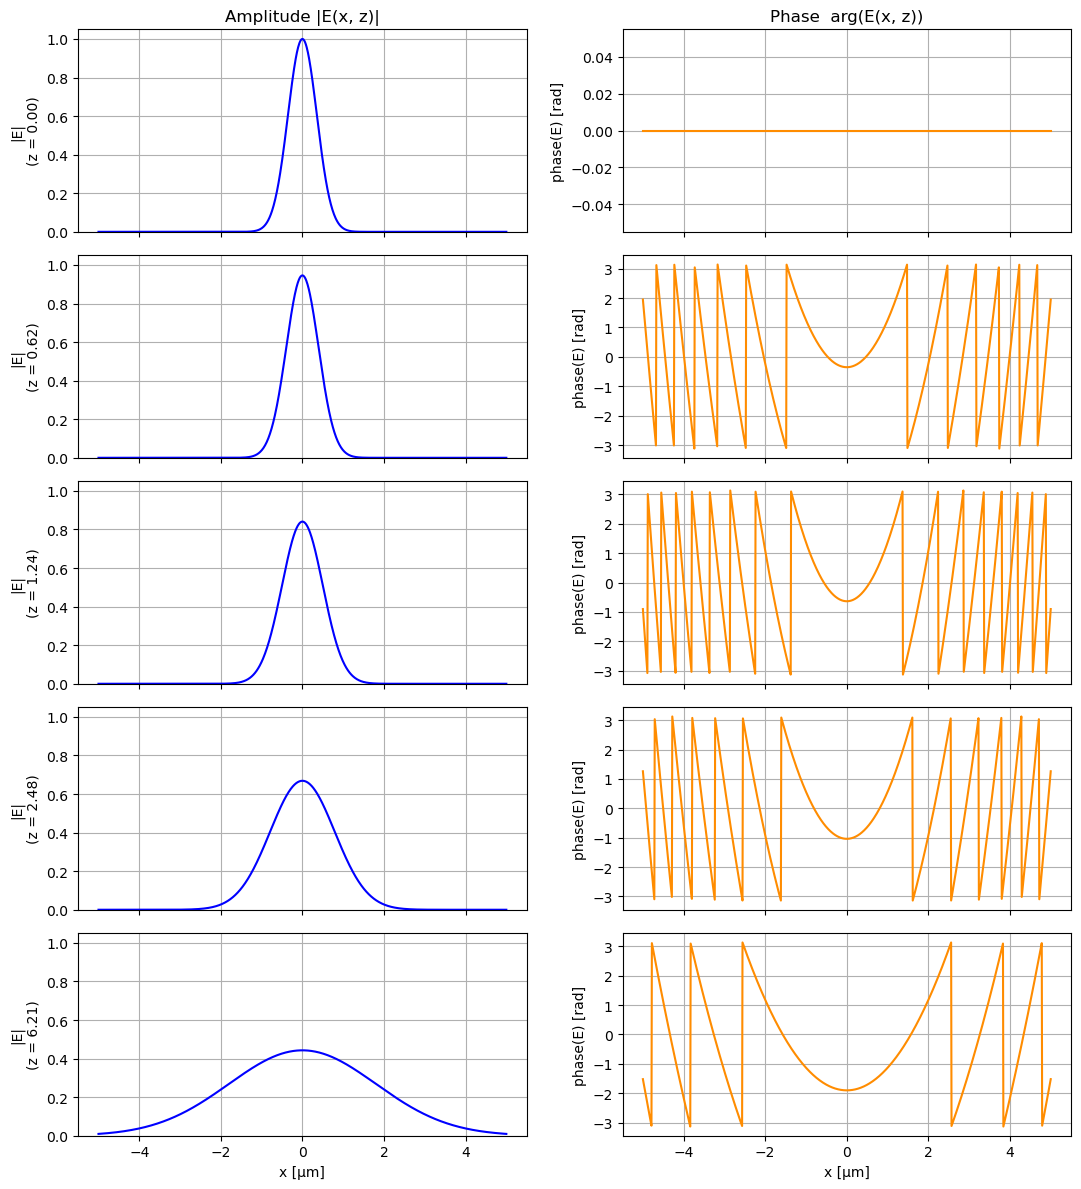

In [3]:
z_values = [0.0, 0.5*zR, zR, 2*zR, 5*zR]

fig, axes = plt.subplots(len(z_values), 2, figsize=(11, 2.4*len(z_values)),
                         sharex=True)

for row, z in enumerate(z_values):
    E, diag = propagate_tilted_gaussian(x, x0, w0, kx, k, z=z)

    # Left column: amplitude
    axes[row, 0].plot(x, np.abs(E), color='blue')
    axes[row, 0].set_ylabel(f"|E|\n(z = {z:.2f})")
    axes[row, 0].grid(True)
    axes[row, 0].set_ylim(0, 1.05)

    # Right column: phase (unwrapped for readability)
    phase = np.angle(E)
    axes[row, 1].plot(x, phase, color='darkorange')
    axes[row, 1].set_ylabel("phase(E) [rad]")
    axes[row, 1].grid(True)

axes[0, 0].set_title("Amplitude |E(x, z)|")
axes[0, 1].set_title("Phase  arg(E(x, z))")
axes[-1, 0].set_xlabel("x [µm]")
axes[-1, 1].set_xlabel("x [µm]")
plt.tight_layout()
plt.show()

## Numerical diagnostics — do the numbers match the textbook?

We print `w(z)`, `R(z)`, Gouy phase, and the beam center at each plane. Sanity checks you can do by eye:
- `w(z)` should equal `w0 * sqrt(1 + (z/zR)^2)`. At z = zR, expect `w0·√2 ≈ 0.707`. At z = 5·zR, expect `w0·√26 ≈ 2.55`.
- `R(z)` should be infinite at z = 0 (flat wavefront), reach a minimum at z = zR (where R = 2·zR), then grow linearly with z.
- Gouy phase `ζ(z) = arctan(z/zR)` should run from 0 at z = 0 to π/4 at z = zR to nearly π/2 at large z.
- Beam center should not move yet (kx = 0).

In [4]:
print(f"{'z':>10}  {'w(z)':>10}  {'R(z)':>14}  {'Gouy [rad]':>12}  {'x_center':>10}")
print("-" * 64)
for z in z_values:
    _, d = propagate_tilted_gaussian(x, x0, w0, kx, k, z=z)
    R_str = "inf" if np.isinf(d["R(z)"]) else f"{d['R(z)']:.4f}"
    print(f"{d['z']:>10.4f}  {d['w(z)']:>10.4f}  {R_str:>14}  {d['Gouy(z)']:>12.4f}  {d['x_center']:>10.4f}")

         z        w(z)            R(z)    Gouy [rad]    x_center
----------------------------------------------------------------
    0.0000      0.5000             inf        0.0000      0.0000
    0.6206      0.5590          3.1029        0.4636      0.0000
    1.2411      0.7071          2.4823        0.7854      0.0000
    2.4823      1.1180          3.1029        1.1071      0.0000
    6.2057      2.5495          6.4540        1.3734      0.0000


## Tilted beamlet — the centroid walks

Now we set `kx` to the largest angle from the GBD_4 basis (θ = 0.1 rad → kx = k·sin(0.1)). Everything else is the same. Look for:
- The amplitude peak shifting to positive x as z grows (the beam is steered).
- The amount it walks should equal `(kx/k)·z = sin(0.1)·z ≈ 0.0998·z` — the diagnostics will confirm this.
- The amplitude shape itself (width, peak height) is identical to the untilted case — tilt and spreading are independent in the paraxial limit.

**LiDAR meaning:** this is the optical equivalent of aiming. A LiDAR scanner imposes a `kx` (and `ky` in 2-D) on each shot; the beam then walks to wherever in the scene that direction points.

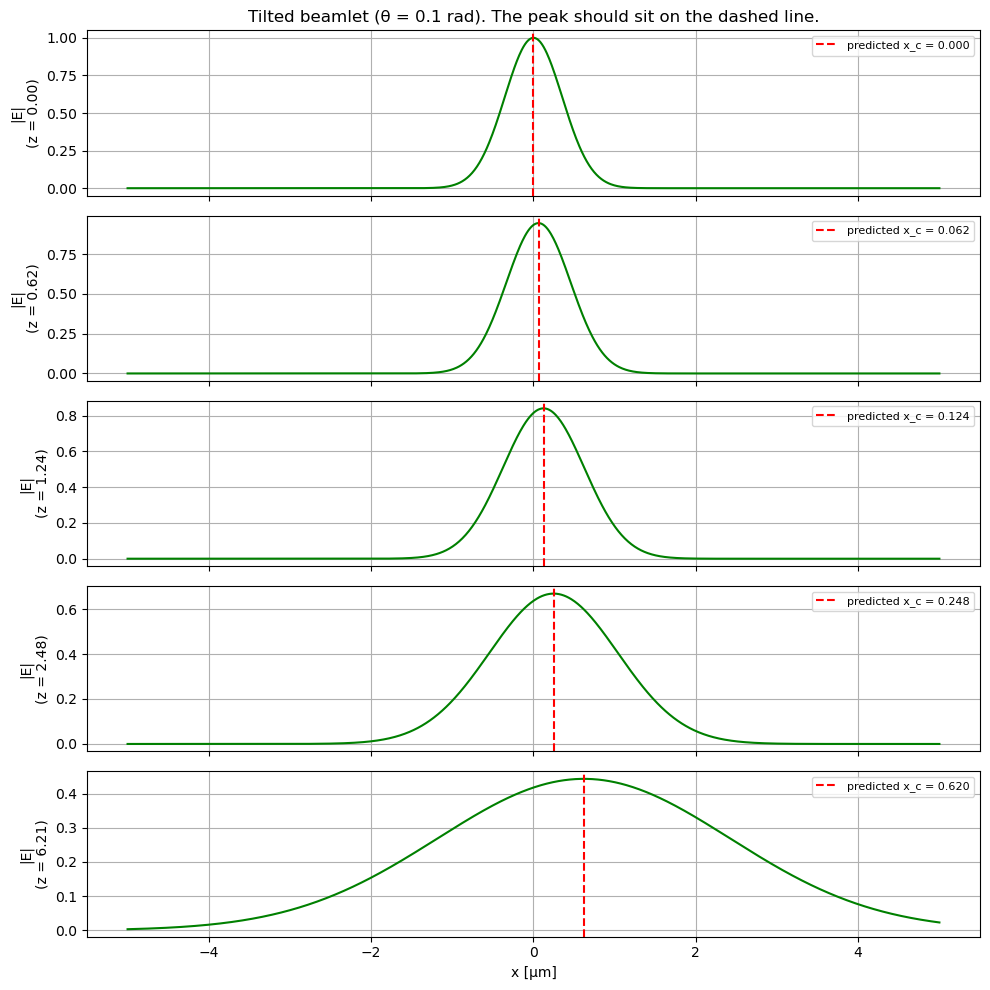


Diagnostics (tilted case):
         z      x_center     expected (kx/k)*z
    0.0000       0.00000               0.00000
    0.6206       0.06195               0.06195
    1.2411       0.12391               0.12391
    2.4823       0.24782               0.24782
    6.2057       0.61954               0.61954


In [5]:
theta = 0.1                 # max angle from the GBD_4 basis (rad)
kx_t = k * np.sin(theta)

fig, axes = plt.subplots(len(z_values), 1, figsize=(10, 2.0*len(z_values)),
                         sharex=True)

for row, z in enumerate(z_values):
    E, diag = propagate_tilted_gaussian(x, x0, w0, kx=kx_t, k=k, z=z)
    axes[row].plot(x, np.abs(E), color='green')
    axes[row].axvline(diag['x_center'], color='red', linestyle='--',
                      label=f"predicted x_c = {diag['x_center']:.3f}")
    axes[row].set_ylabel(f"|E|\n(z = {z:.2f})")
    axes[row].grid(True)
    axes[row].legend(loc='upper right', fontsize=8)

axes[0].set_title(f"Tilted beamlet (θ = {theta} rad). The peak should sit on the dashed line.")
axes[-1].set_xlabel("x [µm]")
plt.tight_layout()
plt.show()

# Numerical confirmation of walking
print("\nDiagnostics (tilted case):")
print(f"{'z':>10}  {'x_center':>12}  {'expected (kx/k)*z':>20}")
for z in z_values:
    _, d = propagate_tilted_gaussian(x, x0, w0, kx=kx_t, k=k, z=z)
    print(f"{z:>10.4f}  {d['x_center']:>12.5f}  {(kx_t/k)*z:>20.5f}")

## What we proved here
1. The propagation function reduces to GBD_4's initial-field formula at z = 0 (zero error).
2. Width, curvature, and Gouy phase all match the textbook closed-form expressions.
3. Tilted beams walk transversely at the predicted rate.
4. The complex field (phase) is preserved at every z — required for FMCW downstream.

## Next notebook: GBD_6
Apply this propagator to **every column** of the GBD_4 basis matrix and sum, weighted by the GBD_4 coefficients, to get `E(x, L)` for the full top-hat field. That's the GBD propagation result. After that (GBD_7) we'll compare against an angular-spectrum FFT reference.